In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#Langsmith Tracking And Tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ['HF_TOKEN']=os.getenv("HF_TOKEN")

In [2]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="deepseek-r1-distill-llama-70b")

In [3]:
from langchain_core.tools import tool

@tool
def multiply(a:int, b:int)->int:
    """multiply two arg a * b"""
    return a * b

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
@tool
def search(query: str):
    """search the web for a query and return the results"""
    tavily=TavilySearchResults()
    result=tavily.invoke(query)
    return f"Result for {query} is: \n{result}"

In [5]:
tools = [multiply, search]
tool_mapping = {tool.name:tool for tool in tools}
tool_mapping

{'multiply': StructuredTool(name='multiply', description='multiply two arg a * b', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x107b780e0>),
 'search': StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x107b7a020>)}

In [6]:
llm_with_tools = llm.bind_tools(tools=tools)

In [7]:
resp = llm_with_tools.invoke("multiply 2 * 3")

In [8]:
resp.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '17ea48r7h',
  'type': 'tool_call'}]

In [9]:
print(tool_mapping[resp.tool_calls[0].get("name")])
print(resp.tool_calls[0]['id'])

name='multiply' description='multiply two arg a * b' args_schema=<class 'langchain_core.utils.pydantic.multiply'> func=<function multiply at 0x107b780e0>
17ea48r7h


In [10]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [11]:
def ai_asistant(state:AgentState):
    message = state["messages"]
    question = message[-1]
    resp = llm_with_tools.invoke(question)
    return {"messages": [resp]}

In [12]:
def router(state:AgentState):
    last_message = state["messages"][-1]
    if len(last_message.tool_calls) > 0:
        return "tools"
    return "end"

In [13]:
def invoke_tool(state: AgentState):
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]  # get the first tool call

    if tool_call['name'] == 'search':
        resp = input(prompt=f'[yes/no], do you want to execute this {tool_call["name"]} expensive operation')
        if resp == 'no':
            raise SystemError

    resp = tool_mapping[tool_call['name']].invoke(tool_call['args'])
    return {"messages": [resp]}

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

graph.add_node("ai_asistant", ai_asistant)
graph.add_node("tools", invoke_tool)

graph.add_conditional_edges(
    'ai_asistant',
    router,
    {
        "tools": "tools",
        "end": END
    }
)

graph.add_edge('tools', END)
graph.set_entry_point("ai_asistant")

app = graph.compile()

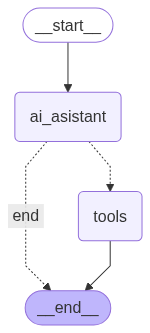

In [15]:

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
from langchain_core.messages import HumanMessage
# app.invoke({"messages": [HumanMessage(content="who is Elon musk")]})
app.invoke({"messages":["What is the current gdp of the india?"]})

{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dxfgsze6g', 'function': {'arguments': '{"query":"current GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 178, 'total_tokens': 297, 'completion_time': 0.529870759, 'prompt_time': 0.018612476, 'queue_time': 0.20073078200000002, 'total_time': 0.548483235}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a8fc06db-f758-4bf0-8d1f-0385e4e42230-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of India'}, 'id': 'dxfgsze6g', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 119, 'total_tokens': 297}),
  'Result for current GDP of India is: \n[{\'title\': \'World GDP Ranking 2025 List - ClearTax\', \'url\': \'https://cleartax.in/s/world-gdp-ranking-lis

In [17]:
app.invoke({"messages":["What is 2 * 3?"]})

{'messages': ['What is 2 * 3?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'x19c442pm', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 224, 'prompt_tokens': 176, 'total_tokens': 400, 'completion_time': 0.980874663, 'prompt_time': 0.010944689, 'queue_time': 0.199684272, 'total_time': 0.991819352}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a54cc490-eb57-4c60-a810-0e797ac39b9e-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'x19c442pm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 224, 'total_tokens': 400}),
  6]}

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition

def ai_asistant_1(stage:AgentState):
    resp = llm_with_tools.invoke(stage["messages"])
    return {"messages": [resp]}

In [19]:
from langgraph.checkpoint.memory import MemorySaver
memorySaver = MemorySaver()

In [20]:
workflow = StateGraph(AgentState)

workflow.add_node("ai_asistant", ai_asistant_1)
workflow.add_node("tools", ToolNode(tools))

workflow.add_conditional_edges("ai_asistant", tools_condition)
workflow.add_edge("tools", "ai_asistant")
workflow.add_edge(START, "ai_asistant")

app = workflow.compile(checkpointer=memorySaver, interrupt_before=["tools"])

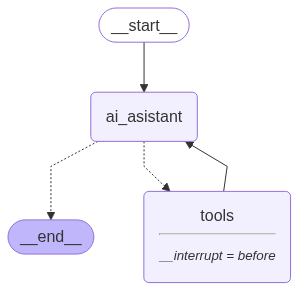

In [21]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
from langchain_core.messages import HumanMessage
config = {"configurable":{"thread_id": "2"}}

response=app.invoke({"messages":[HumanMessage("What is the current gdp of the china?")]},config=config)
response

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7r4cjct5h', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 178, 'total_tokens': 284, 'completion_time': 0.424765254, 'prompt_time': 0.011061647, 'queue_time': 0.20043801, 'total_time': 0.435826901}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1b0b3b6d-f80a-44df-8d17-b4a2509c2199-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '7r4cjct5h', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 106, 'total_tokens': 284})]}

In [23]:
snapshot = app.get_state(config=config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7r4cjct5h', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 178, 'total_tokens': 284, 'completion_time': 0.424765254, 'prompt_time': 0.011061647, 'queue_time': 0.20043801, 'total_time': 0.435826901}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1b0b3b6d-f80a-44df-8d17-b4a2509c2199-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '7r4cjct5h', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 106, 'total_tokens': 284})]}, next=('tools',), config={'configurable': {'thread_id': '2', 'checkpoint_ns

StateSnapshot(values={'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5vamwq6hf', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 178, 'total_tokens': 301, 'completion_time': 0.528414894, 'prompt_time': 0.018543436, 'queue_time': 0.199855375, 'total_time': 0.54695833}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b56a49e2-39f6-4738-97c9-46005bb45afd-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '5vamwq6hf', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 123, 'total_tokens': 301})]}, next=('tools',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0552c8-67df-6f06-8001-fc92df628dd5'}}, metadata={'source': 'loop', 'writes': {'ai_asistant': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5vamwq6hf', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 178, 'total_tokens': 301, 'completion_time': 0.528414894, 'prompt_time': 0.018543436, 'queue_time': 0.199855375, 'total_time': 0.54695833}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b56a49e2-39f6-4738-97c9-46005bb45afd-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '5vamwq6hf', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 123, 'total_tokens': 301})]}}, 'step': 1, 'parents': {}, 'thread_id': '1'}, created_at='2025-06-29T21:03:37.181153+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0552c8-5d86-6a0a-8000-173d222f8606'}}, tasks=(PregelTask(id='cda6f23d-8e95-ff01-6cff-8b22ccfba08d', name='tools', path=('__pregel_pull', 'tools'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [24]:
snapshot.next

('tools',)

In [25]:
last_message = snapshot.values["messages"][-1]
last_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7r4cjct5h', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 178, 'total_tokens': 284, 'completion_time': 0.424765254, 'prompt_time': 0.011061647, 'queue_time': 0.20043801, 'total_time': 0.435826901}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1b0b3b6d-f80a-44df-8d17-b4a2509c2199-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': '7r4cjct5h', 'type': 'tool_call'}], usage_metadata={'input_tokens': 178, 'output_tokens': 106, 'total_tokens': 284})

In [26]:
tool_calls = last_message.tool_calls
tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of China'},
  'id': '7r4cjct5h',
  'type': 'tool_call'}]

In [28]:
if tool_calls[0]['name'] == "search":
    user_input = input(prompt=f"[yes/no] do you want to perform {tool_calls[0]['name']} operation")
    if user_input == 'no':
        print("web tool discarded")
        raise Exception("Web tool discarded by the user.")
    resp = app.invoke(None, config)
    print(resp)
resp = app.invoke(None, config)

web tool discarded


Exception: Web tool discarded by the user.